![Los Angeles skyline](la_skyline.jpg)

Los Angeles, California 😎. The City of Angels. Tinseltown. The Entertainment Capital of the World! 

Known for its warm weather, palm trees, sprawling coastline, and Hollywood, along with producing some of the most iconic films and songs. However, as with any highly populated city, it isn't always glamorous and there can be a large volume of crime. That's where you can help!

You have been asked to support the Los Angeles Police Department (LAPD) by analyzing crime data to identify patterns in criminal behavior. They plan to use your insights to allocate resources effectively to tackle various crimes in different areas.

## The Data

They have provided you with a single dataset to use. A summary and preview are provided below.

It is a modified version of the original data, which is publicly available from Los Angeles Open Data.

# crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

In [147]:
# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
crimes = pd.read_csv("crimes.csv", dtype={"TIME OCC": str})
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [148]:
# Start coding here
# Use as many cells as you need

# Inspect dataset structure, data types, and missing values
print(crimes.shape)
print(crimes.info())

for column in crimes.columns:
    print(f'{column}:', crimes[column].nunique())
    print('Null:', crimes[column].isna().sum())
    
# Date OCC and Vict Age were both objects, so I converted them to the proper datatype.
crimes['DATE OCC'] = pd.to_datetime(crimes['DATE OCC'])
crimes['Date Rptd'] = pd.to_datetime(crimes['Date Rptd'])
crimes['Vict Age'] = crimes['Vict Age'].astype(int)

(185715, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         185715 non-null  int64 
 1   Date Rptd     185715 non-null  object
 2   DATE OCC      185715 non-null  object
 3   TIME OCC      185715 non-null  object
 4   AREA NAME     185715 non-null  object
 5   Crm Cd Desc   185715 non-null  object
 6   Vict Age      185715 non-null  int64 
 7   Vict Sex      185704 non-null  object
 8   Vict Descent  185705 non-null  object
 9   Weapon Desc   73502 non-null   object
 10  Status Desc   185715 non-null  object
 11  LOCATION      185715 non-null  object
dtypes: int64(2), object(10)
memory usage: 17.0+ MB
None
DR_NO: 185715
Null: 0
Date Rptd: 398
Null: 0
DATE OCC: 1152
Null: 0
TIME OCC: 1439
Null: 0
AREA NAME: 21
Null: 0
Crm Cd Desc: 104
Null: 0
Vict Age: 98
Null: 0
Vict Sex: 4
Null: 11
Vict Descent: 20
Null: 10
Weapon Desc

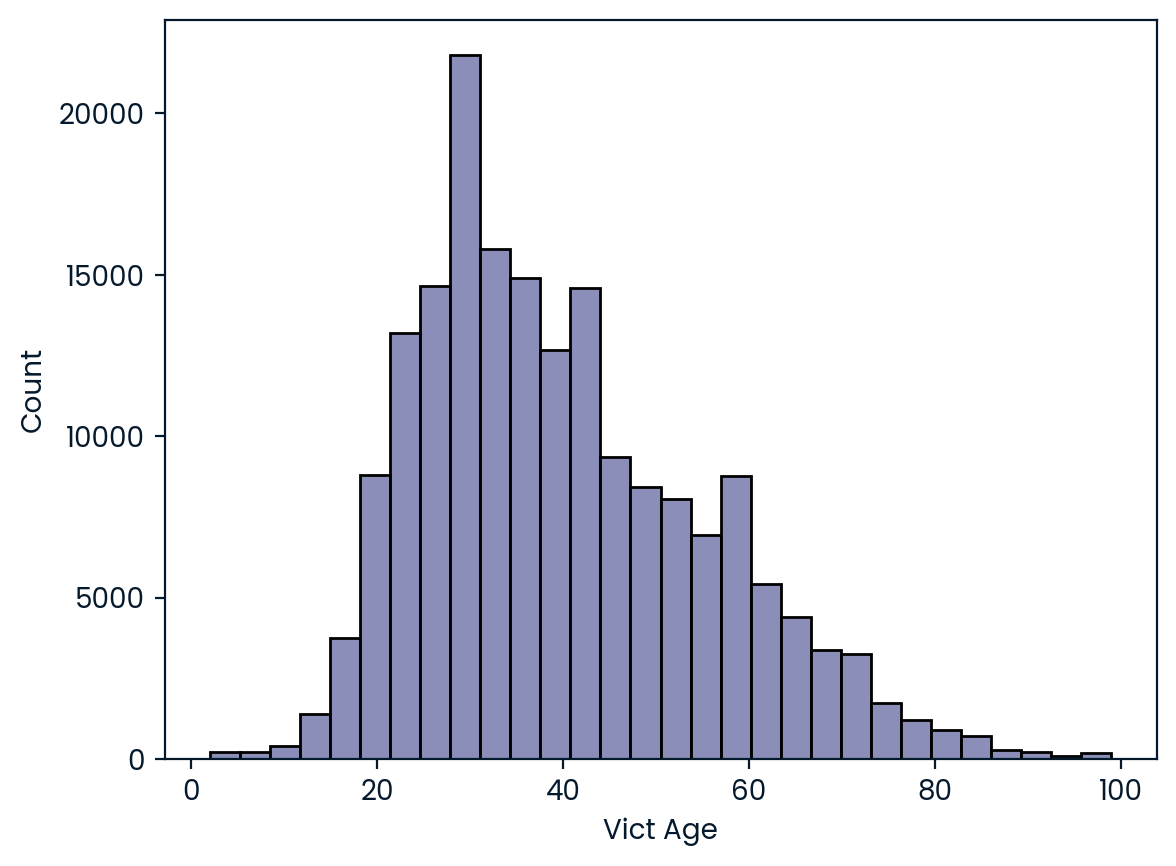

In [149]:
# Exploratory Data Analysis
# What age groups are most affected?
sns.histplot(
    data=crimes,
    x='Vict Age',
    bins=30
)

plt.show()

# This suggests that younger adults are more represented in reported incidents, though this may reflect exposure, reporting behavior, or population structure rather than actual risk alone.

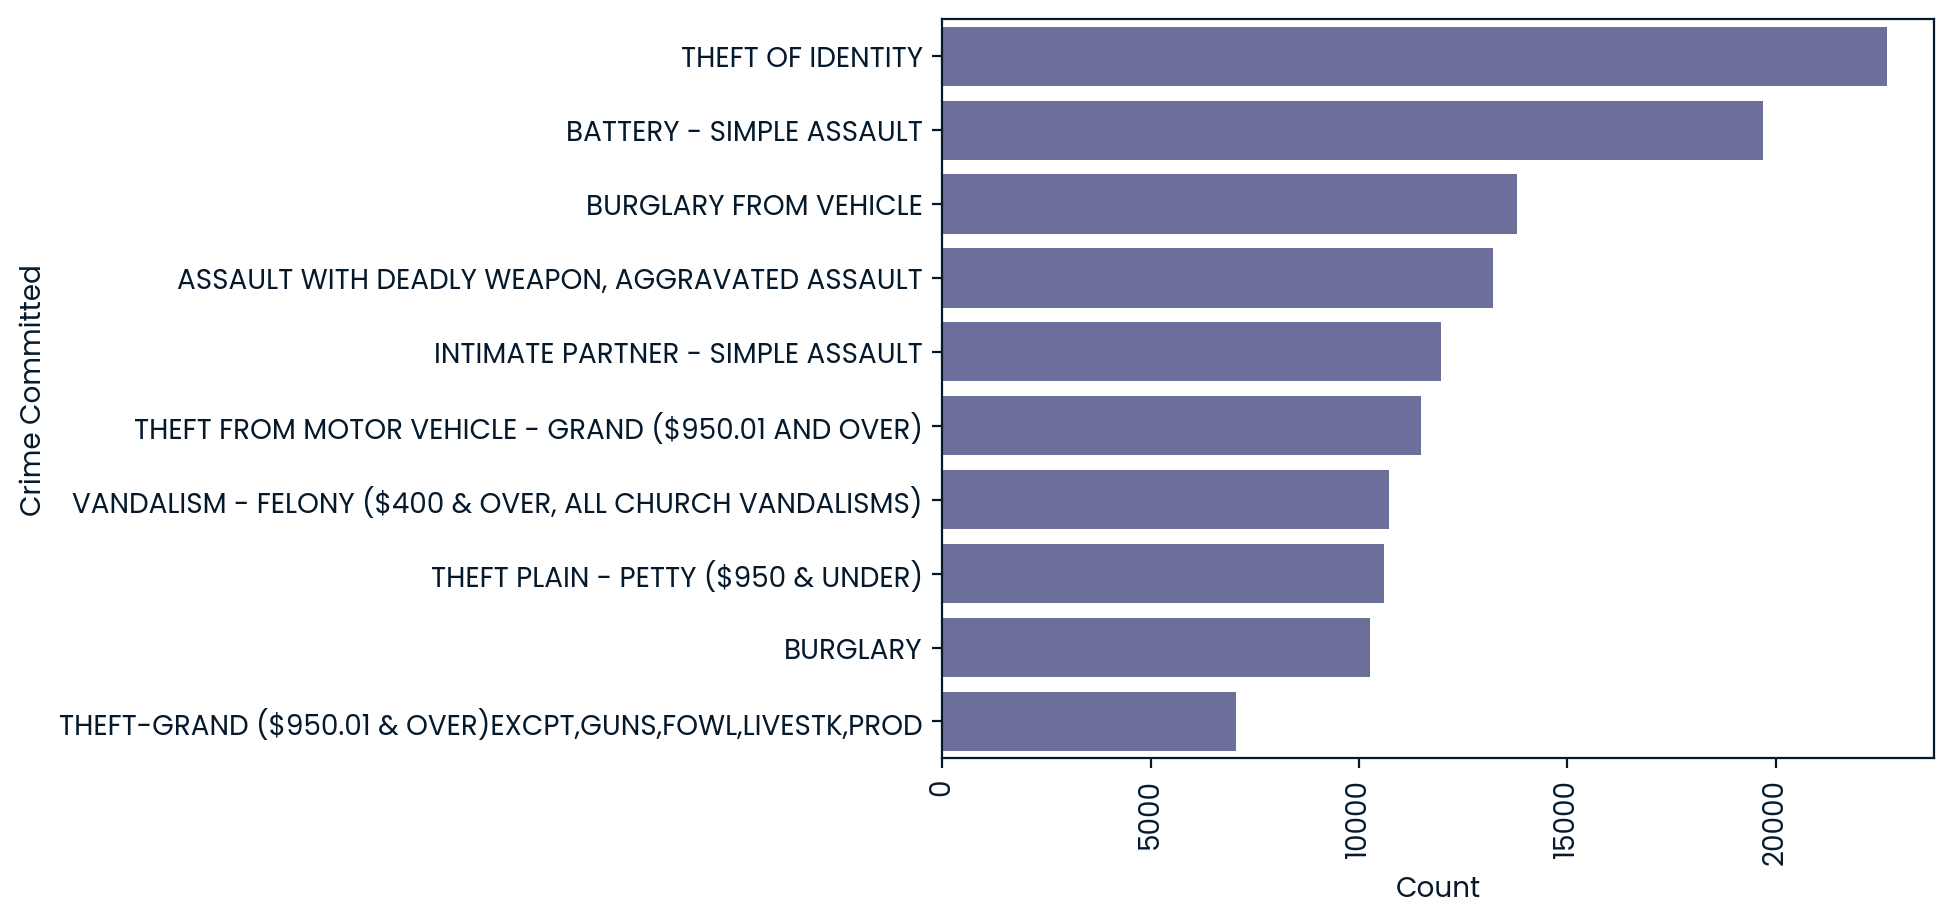

In [150]:
# Exploratory Data Analysis
# Crime type frequency

top_10 = crimes['Crm Cd Desc'].value_counts().head(10).index
top_crimes = crimes[crimes['Crm Cd Desc'].isin(top_10)]

g = sns.countplot(
    data=top_crimes,
    y='Crm Cd Desc',
    order=top_10
)
g.set(
    xlabel='Count',
    ylabel='Crime Committed'
)
plt.xticks(rotation=90)
plt.show()

# Identity theft appears as the most frequent crime category among the top reported offenses, followed by simple assault and vehicle-related burglary. This suggests that a significant portion of reported incidents are non-violent or property-related crimes.

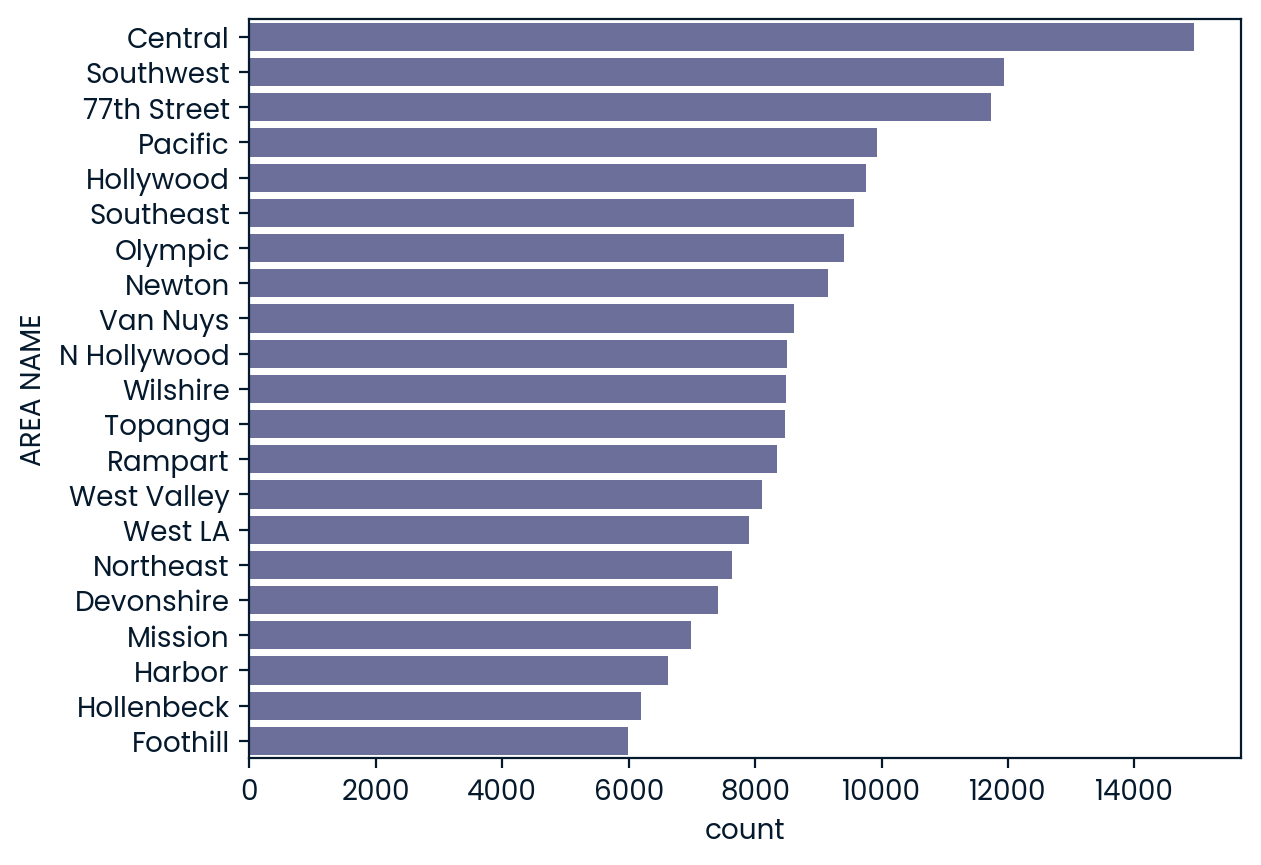

In [151]:
# Exploratory Data Analysis
# Crime by area
order = crimes['AREA NAME'].value_counts().index
sns.countplot(
    data=crimes,
    y='AREA NAME',
    order=order
)

plt.show()
# The visualization shows that Central area has the highest number of reported incidents, followed by Southwest and 77th Street areas.

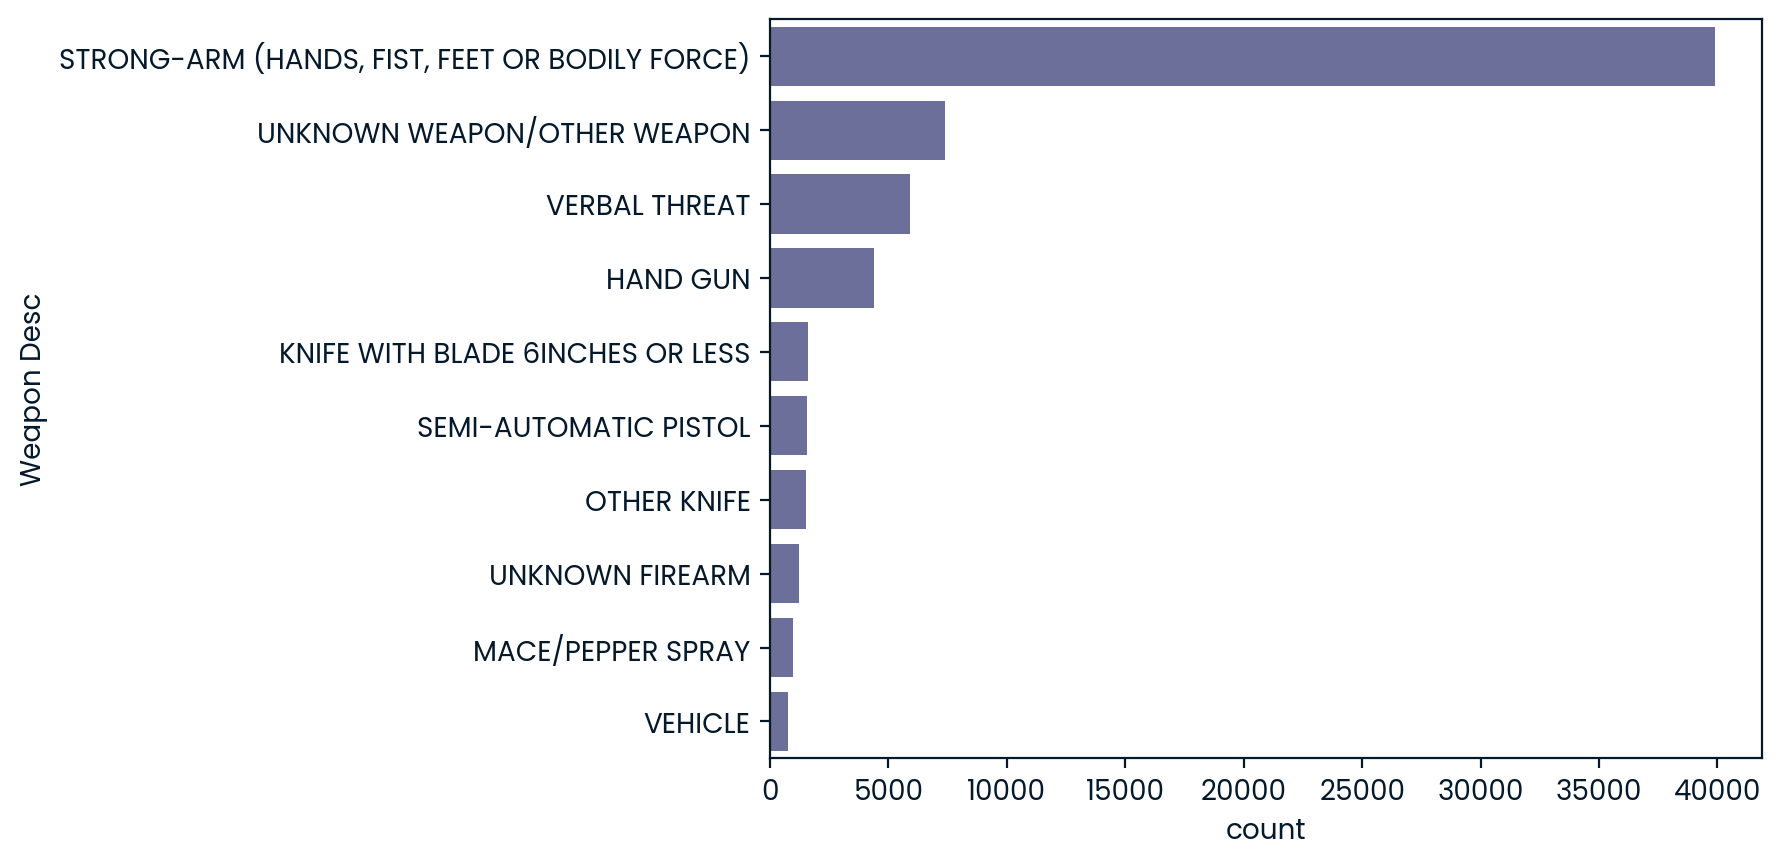

In [152]:
# Exploratory Data Analysis
# Weapon usage check

top_10_weapons = crimes['Weapon Desc'].value_counts().head(10).index
top_weapons = crimes[crimes['Weapon Desc'].isin(top_10_weapons)]
sns.countplot(
    data=top_weapons,
    y='Weapon Desc',
    order=top_10_weapons
)

plt.show()
# The most frequently recorded entry in Weapon Desc is “strong-arm,” which indicates the use of physical force rather than a weapon. This is followed by “unknown weapon” and “verbal threat,” suggesting that many incidents involve non-weapon force or incomplete weapon reporting.

12


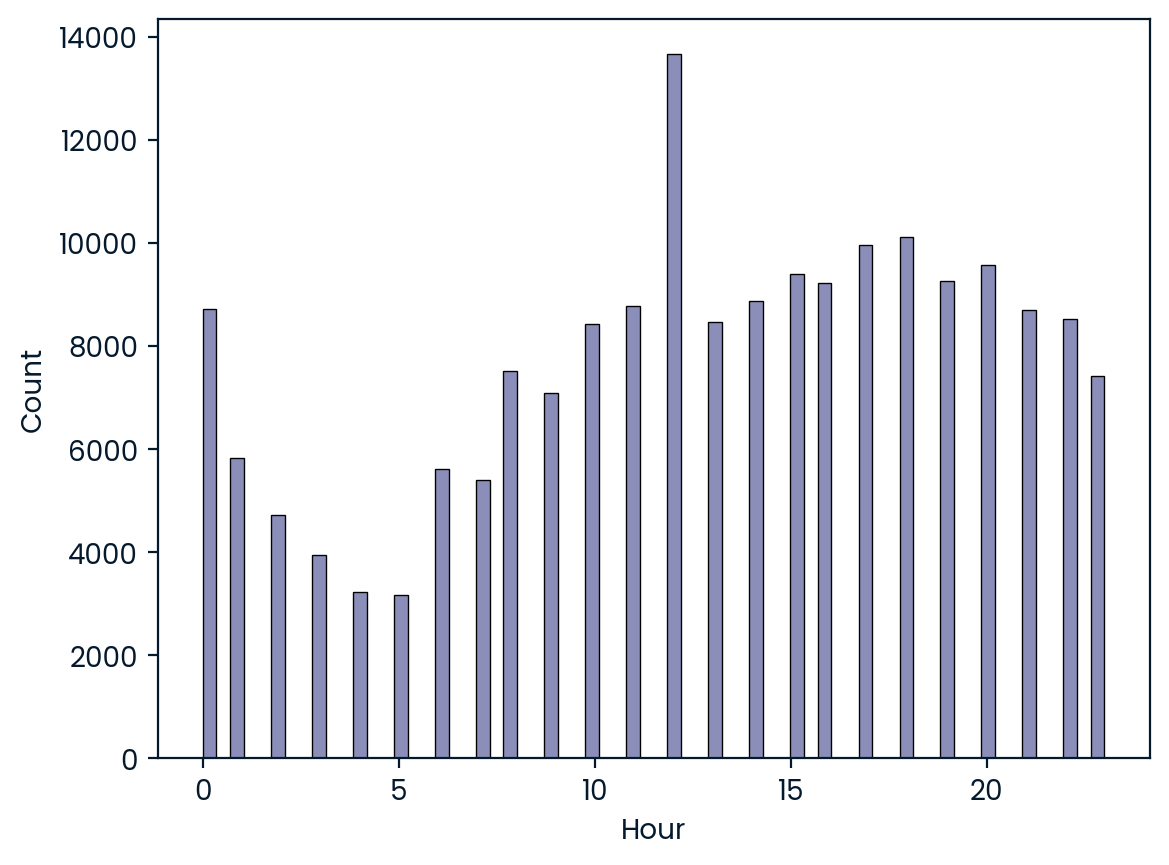

In [153]:
# ACTUAL
# Which hour has the highest frequency of crimes? Store as an integer variable called peak_crime_hour
crimes['Hour'] = crimes['TIME OCC'].str[:2].astype(int)
crimes['Minute'] = crimes['TIME OCC'].str[2:].astype(int)

sns.histplot(
    data=crimes,
    x='Hour'
)

peak_crime_hour = crimes['Hour'].value_counts().idxmax()
print(peak_crime_hour)
plt.show()

# The most common hour for reported incidents in the dataset is 12 (noon).

Central


<AxesSubplot: xlabel='count', ylabel='AREA NAME'>

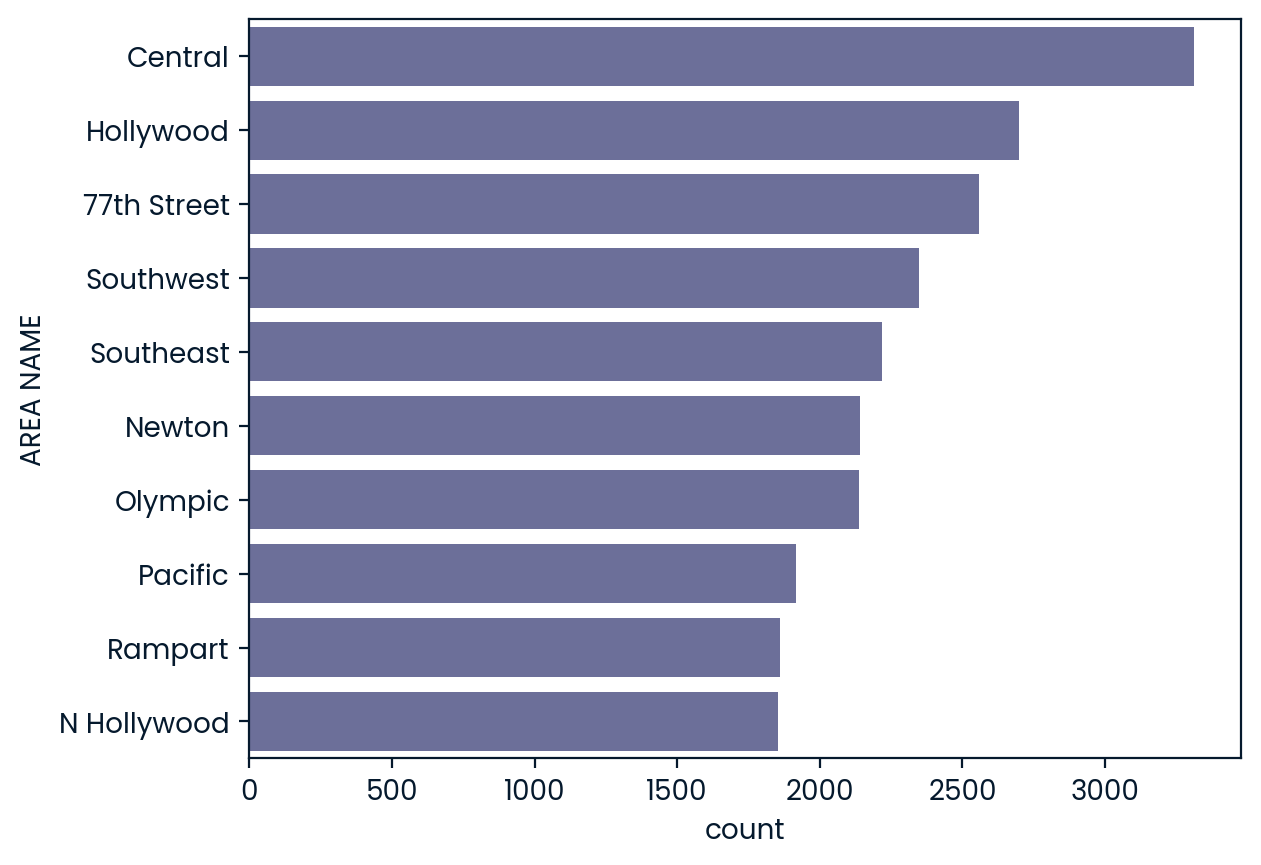

In [154]:
# Which area has the largest frequency of night crimes (crimes committed between 10pm and 3:59am)? Save as a string variable called peak_night_crime_location.

night_crimes = crimes.loc[
    (crimes['Hour'] >= 22) | (crimes['Hour'] < 4)
]

top_10_night_locations = night_crimes['AREA NAME'].value_counts().head(10).index
locations = night_crimes[night_crimes['AREA NAME'].isin(top_10_night_locations)]

peak_night_crime_location = night_crimes['AREA NAME'].value_counts().idxmax()
print(peak_night_crime_location)

sns.countplot(
    data = locations,
    y = 'AREA NAME',
    order=top_10_night_locations
)

# The Central area has the highest number of reported night-time incidents (10 PM–4 AM) in the dataset.

[]

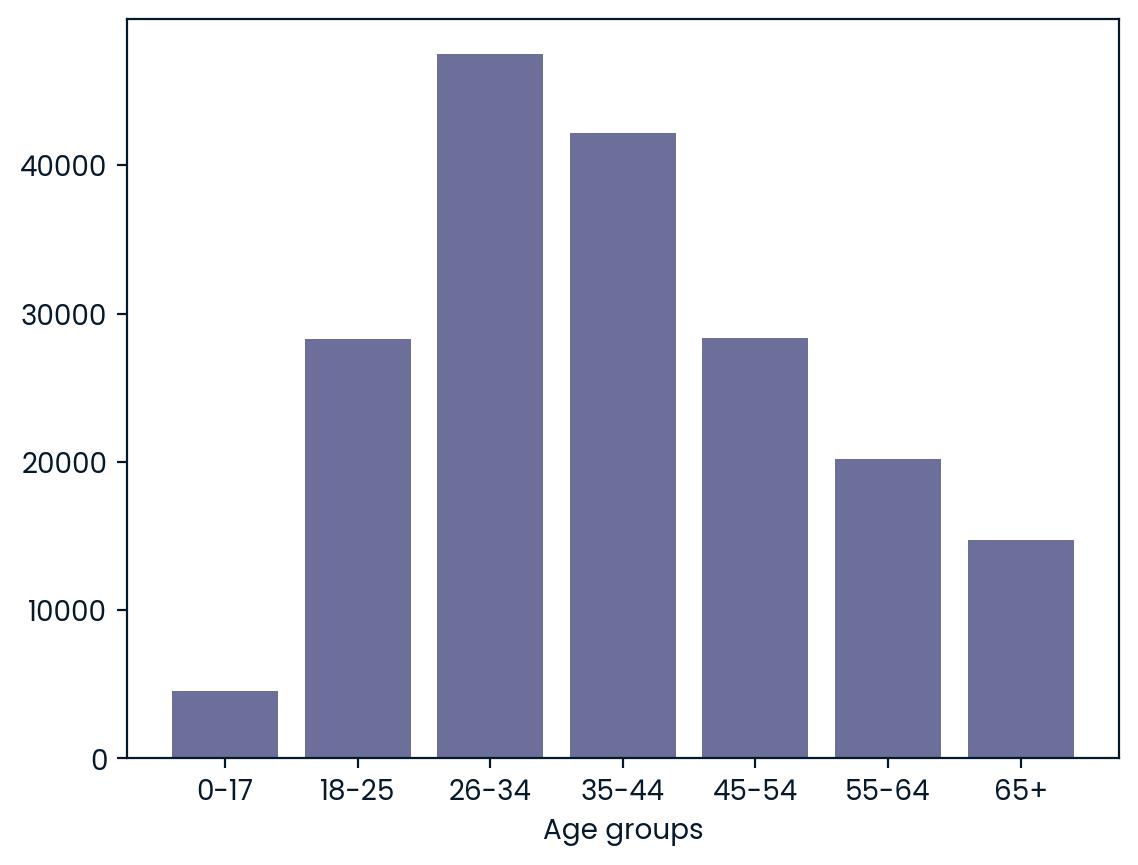

In [155]:
# Identify the number of crimes committed against victims of different age groups. Save as a pandas Series called victim_ages, with age group labels "0-17", "18-25", "26-34", "35-44", "45-54", "55-64", and "65+" as the index and the frequency of crimes as the values.

victim_ages = pd.cut(
    crimes['Vict Age'],
    bins=[0, 17, 25, 34, 44, 54, 64, 120],
    labels=['0-17','18-25','26-34','35-44','45-54','55-64','65+']
).value_counts().sort_index()

g = sns.barplot(x=victim_ages.index, y=victim_ages.values)
g.set(
    xlabel = 'Age groups'
)
plt.plot()


# The plot shows that reported incidents are most frequent among victims in the 18–25 and 26–34 age groups, indicating that younger adults make up a larger share of cases in this dataset.